In [8]:
import setup
from importlib import reload
reload(setup)
from setup import *

# 1D Fickian diffusion 
henry_constant = 9.3e-4 * 1000 # mol/m^3/atm for CO in water at 293.15K 
diffusion_coefficient = 1.91e-9 # m2/s for CO in water at 293.15K 
A_site = F * 1e-4 / (210e-6 * N_A) # Surface area of a single Pt site: 1cm2 = 210uC (HUPD)
delta_BL_micron = 1e-6 # Setting the denominator to 1 micron to allow for delta_BL to be in microns
k1_fick = diffusion_coefficient * henry_constant * N_A * A_site / delta_BL_micron
log_k1_fick = np.log(k1_fick)

# ER 2 

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.43,15
,3000,0,0.49,15
,3000,0,0.47,15
,3000,0,0.44,7


Computed from 4000 posterior samples and 2324 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  4535.87    63.58
p_loo       10.38        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     2324  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



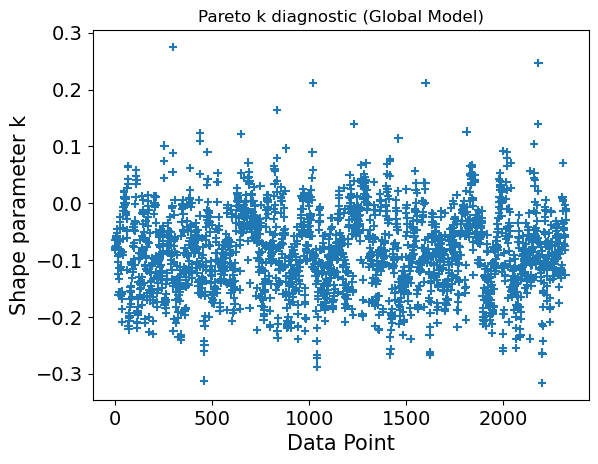

In [ ]:
with pm.Model() as ER_2:
    '''
    1. CO + * <-> CO* (QEA)
    2. CO* + OH- -> COOH* + (e-) (RDS)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.Normal('deltaG1_0', mu=-0.4, sigma=0.2)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.2) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)   
    Gact2_0 = pm.Normal('Gact2_0', mu=0.7, sigma=0.2) # at 0V_SHE

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    Gact2 = Gact2_0 - beta_2*E_in
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH = log_K4 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH]), axis=0)
    log_theta_CO = term_CO + log_theta
    log_theta_OH = term_OH + log_theta

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pt.exp(log_theta_OH))
    theta_empty = pm.Deterministic('theta_empty', pt.exp(log_theta))

    # Rate expression
    log_rate = log_k2 + log_theta_CO + np.log(C_KOH_in)
    rate = observables(log_rate) 

trace_ER_2, loo_ER_2 = fit_and_evaluate(ER_2)

            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG1_0 -0.110  0.001  -0.113   -0.107        0.0      0.0    2223.0    2674.0    1.0
deltaG4_0  0.041  0.005   0.031    0.050        0.0      0.0    2125.0    2449.0    1.0
Gact2_0    0.752  0.000   0.752    0.753        0.0      0.0    3060.0    2258.0    1.0
beta_2     0.255  0.003   0.249    0.262        0.0      0.0    2569.0    2552.0    1.0
sigma_rel  0.155  0.006   0.143    0.167        0.0      0.0    1613.0    2405.0    1.0
exponent   0.560  0.013   0.536    0.585        0.0      0.0    1594.0    2289.0    1.0


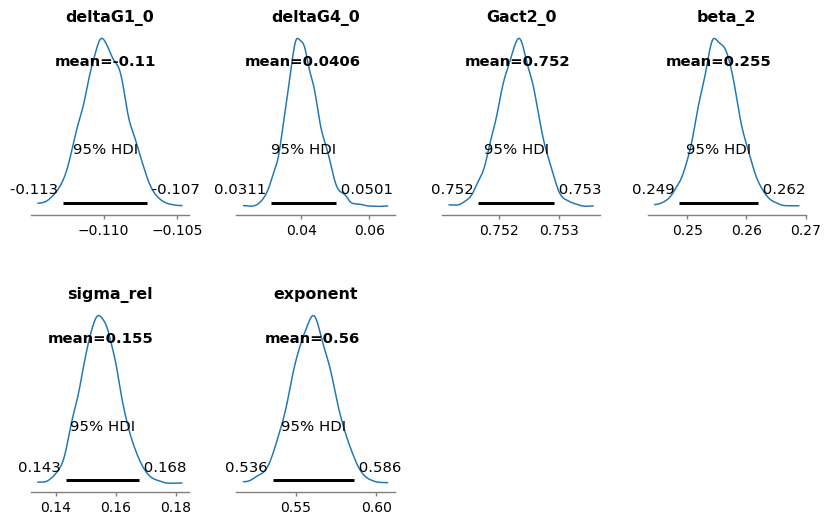

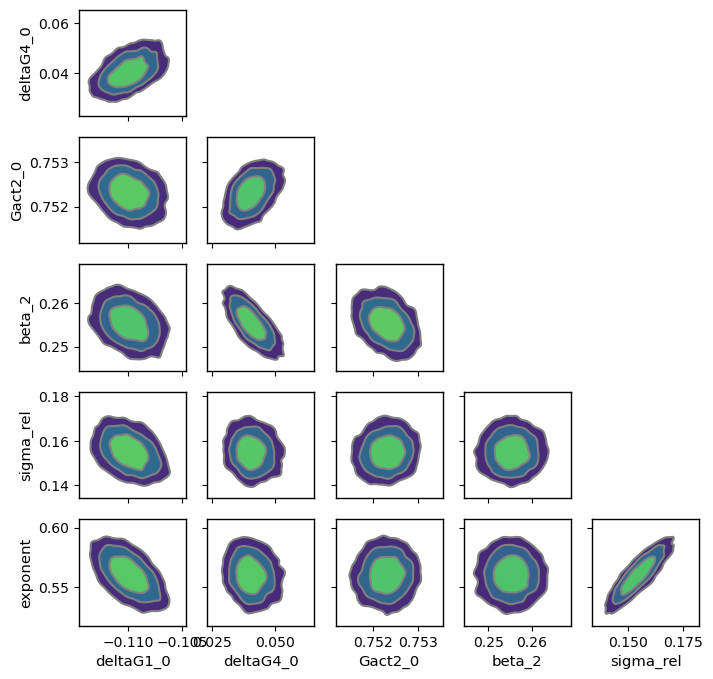

Sampling: [rate]


rate: 0.836


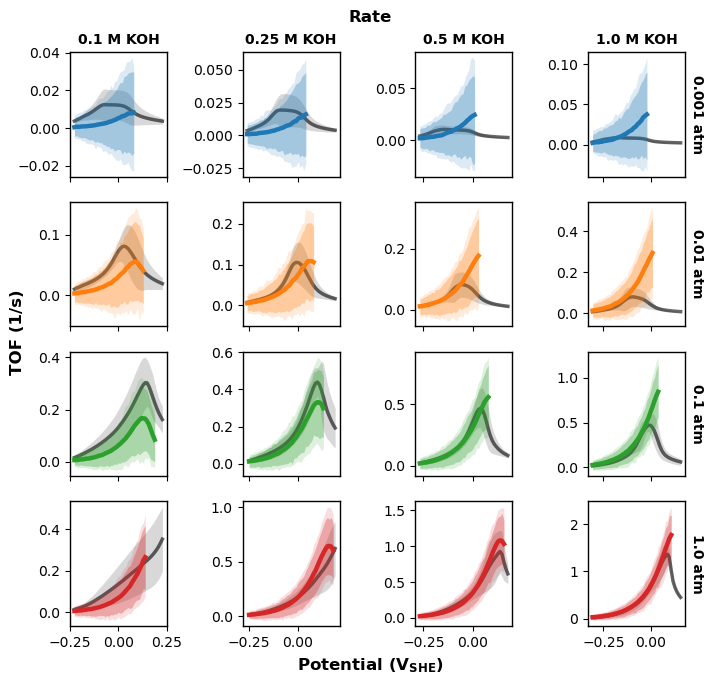

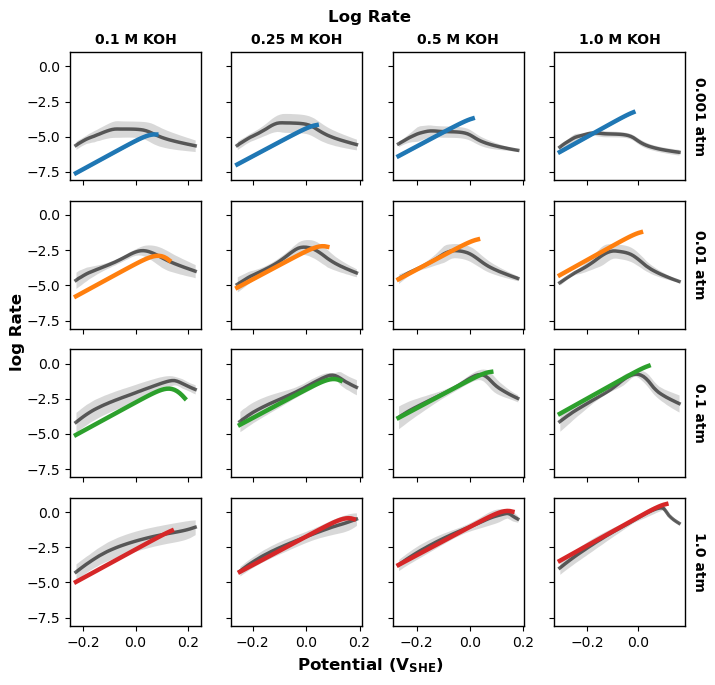

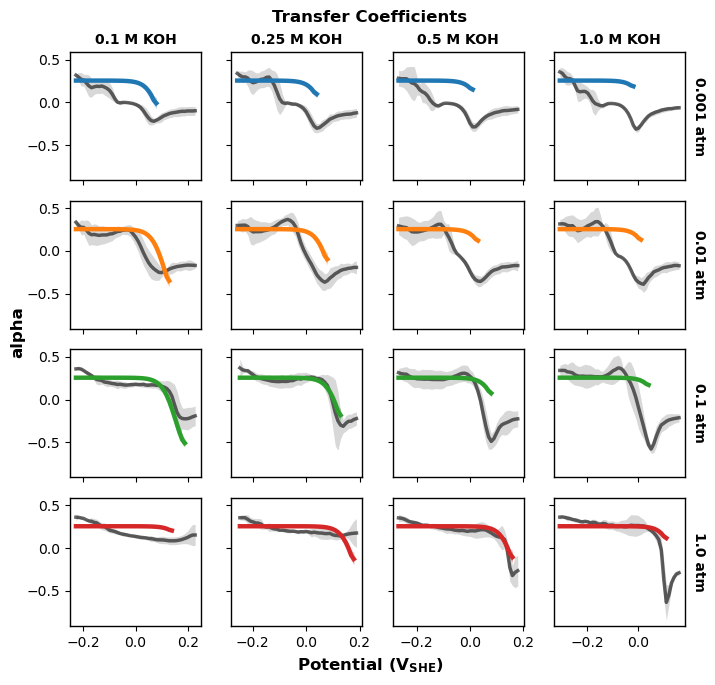

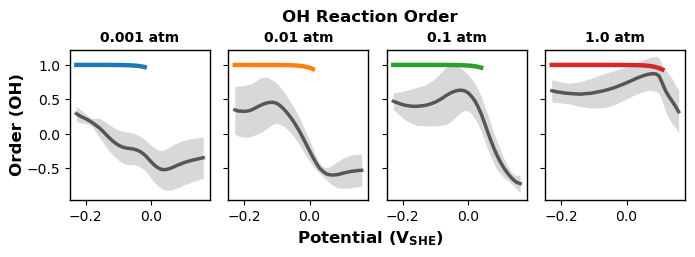

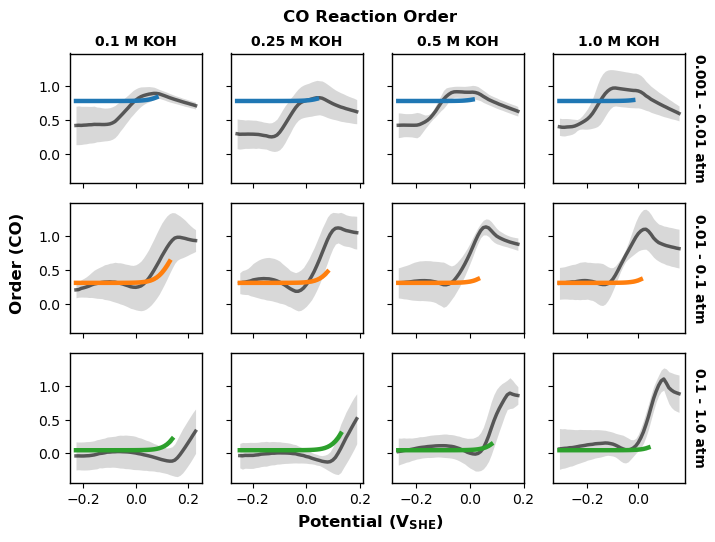

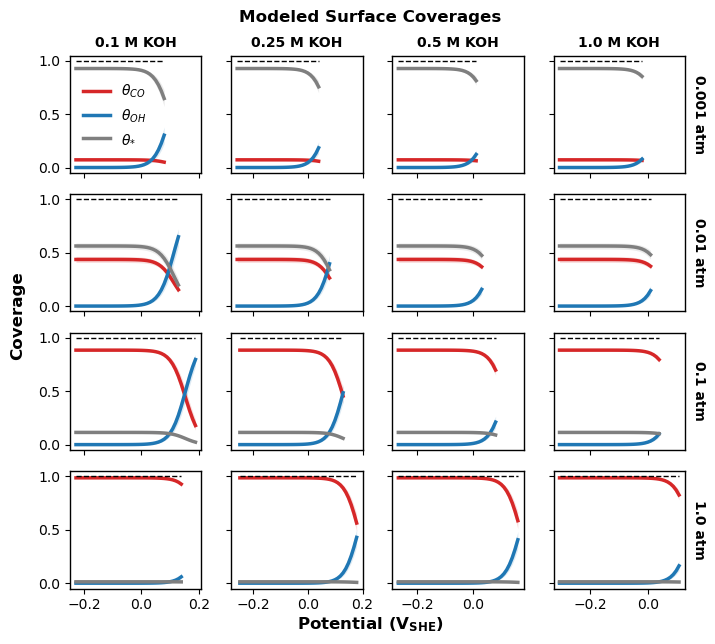

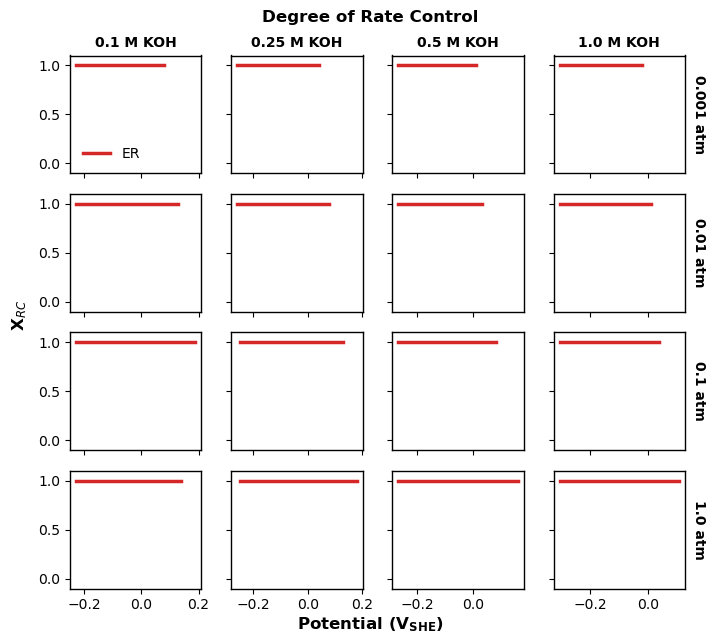

In [9]:
ppc_ER_2 = plot_posteriors(trace_ER_2, ER_2, plot_target)
plot_model_fits(trace_ER_2, ppc_ER_2); plot_coverages(trace_ER_2)
plot_drc(ER_2, trace_ER_2, perturb_vars=['Gact2_0'], perturb_labels=['ER'], target=plot_target)

# ER 1 2

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.48,15
,3000,0,0.44,7
,3000,0,0.46,11
,3000,0,0.49,7


Computed from 4000 posterior samples and 2324 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  5170.39    72.61
p_loo        8.08        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     2324  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



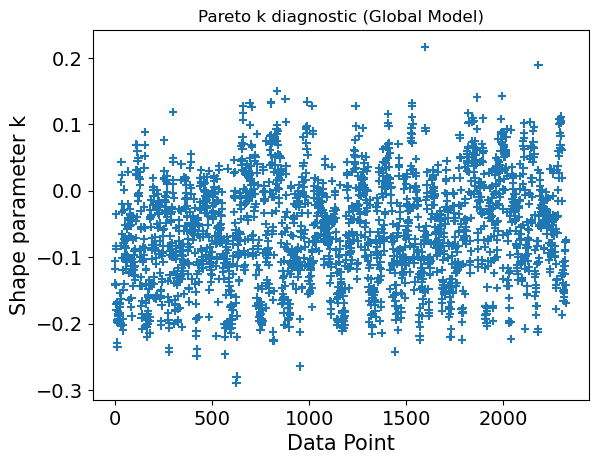

In [4]:
with pm.Model() as ER_1_2: 
    '''
    1. CO + * -> CO* (Fick) (Irr) (SSA)
    2. CO* + OH- -> COOH* + (e-) (SSA)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Fast)
    4. OH- + * <-> OH* + (e-) (QEA)
    '''
    # Priors
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.0, sigma=0.1) # at 0V_SHE
    beta_2 = pm.Beta('beta_2', alpha=5, beta=5)
    Gact2_0 = pm.Normal('Gact2_0', mu=0.75, sigma=0.1) # at 0V_SHE
    delta_BL = pm.TruncatedNormal('delta_BL', mu=10, sigma=5, lower=0) # in microns

    # Thermodynamics 
    deltaG4 = deltaG4_0 - E_in
    Gact2 = Gact2_0 - beta_2*E_in
    log_K4 = -deltaG4/(kb_eV*T)
    log_k1 = log_k1_fick - pt.log(delta_BL)
    log_k2 = np.log(kb_J*T/h) - Gact2/(kb_eV*T)

    term_CO = log_k1 + np.log(P_CO_in) - (log_k2 + np.log(C_KOH_in))
    term_OH = log_K4 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH]), axis=0)
    log_theta_CO = term_CO + log_theta
    log_theta_OH = term_OH + log_theta

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pt.exp(log_theta_OH))
    theta_empty = pm.Deterministic('theta_empty', pt.exp(log_theta))

    # Rate expression
    log_rate = log_k2 + np.log(C_KOH_in) + log_theta_CO 
    rate = observables(log_rate)

trace_ER_1_2, loo_ER_1_2 = fit_and_evaluate(ER_1_2)

            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG4_0  0.089  0.003   0.085    0.094      0.000    0.000    3413.0    3203.0    1.0
Gact2_0    0.747  0.000   0.747    0.748      0.000    0.000    2326.0    2596.0    1.0
beta_2     0.277  0.003   0.271    0.283      0.000    0.000    2638.0    2598.0    1.0
delta_BL   8.801  0.192   8.451    9.160      0.003    0.003    4181.0    3024.0    1.0
sigma_rel  0.214  0.010   0.196    0.233      0.000    0.000    1276.0    1948.0    1.0
exponent   0.802  0.015   0.773    0.831      0.000    0.000    1302.0    1964.0    1.0


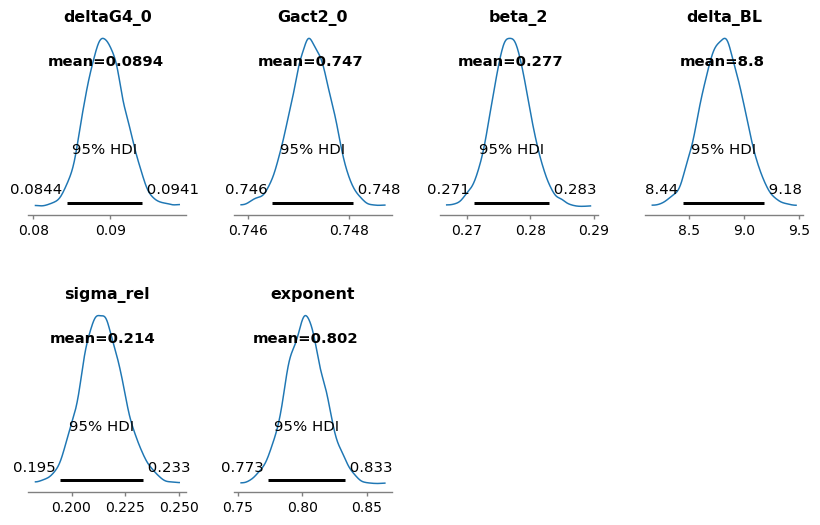

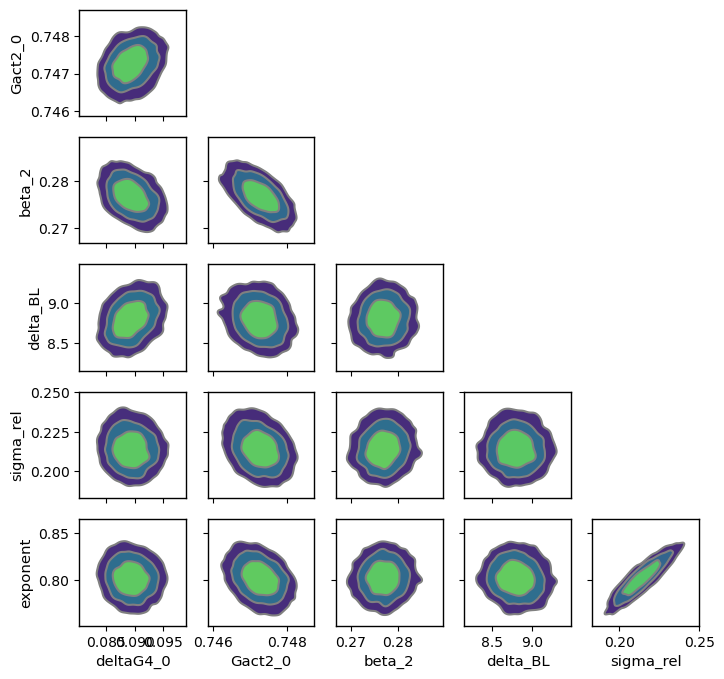

Sampling: [rate]


rate: 0.831


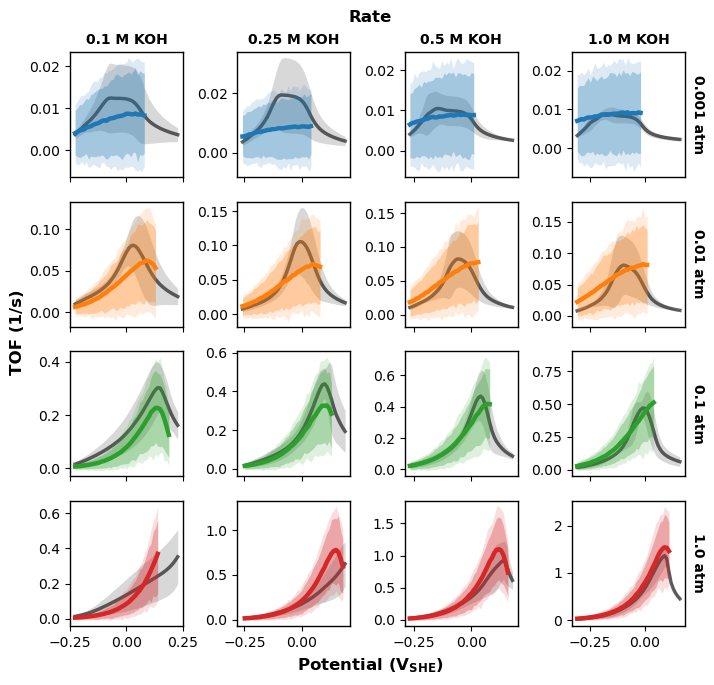

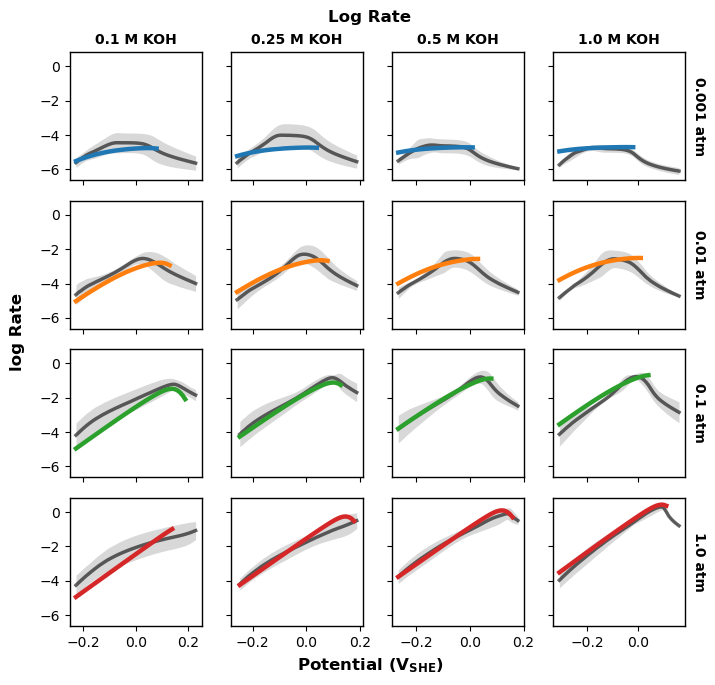

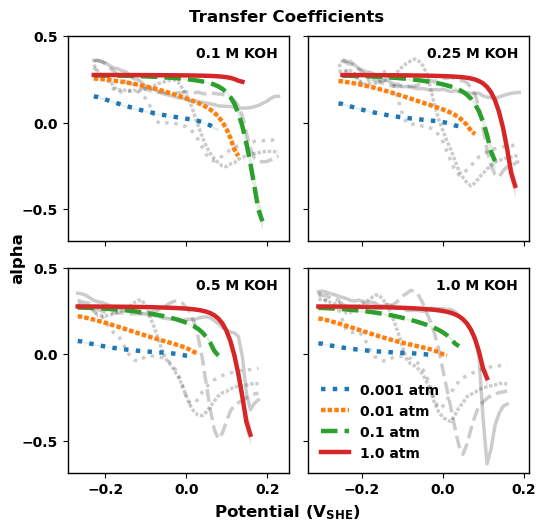

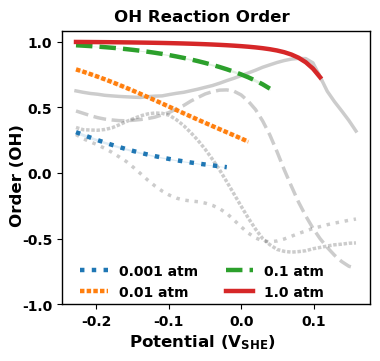

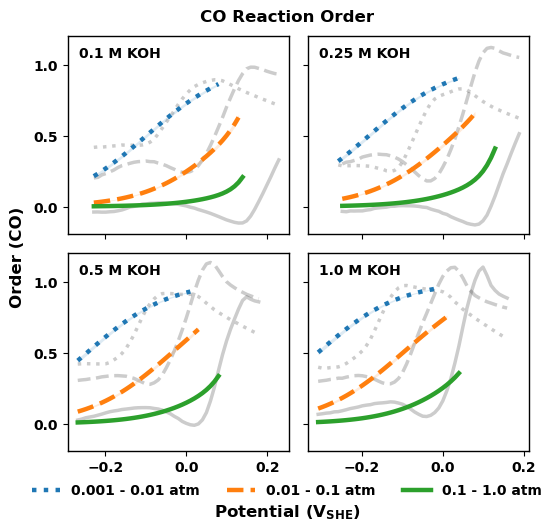

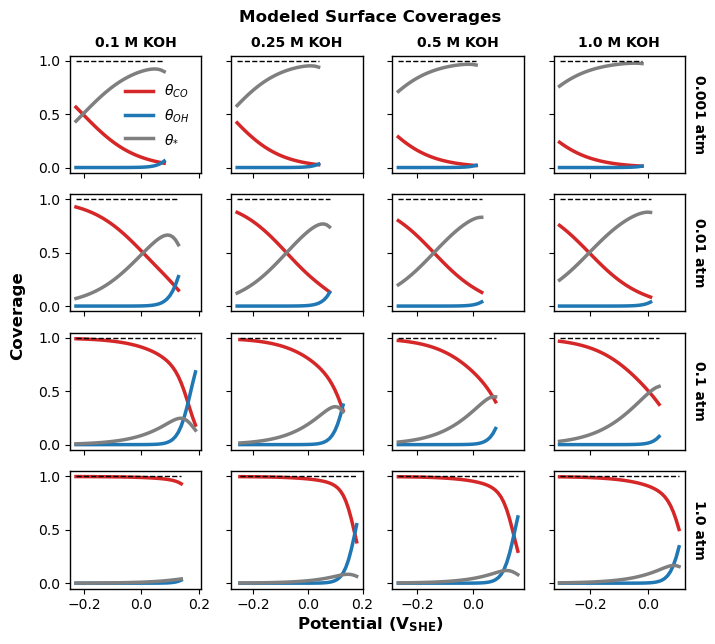

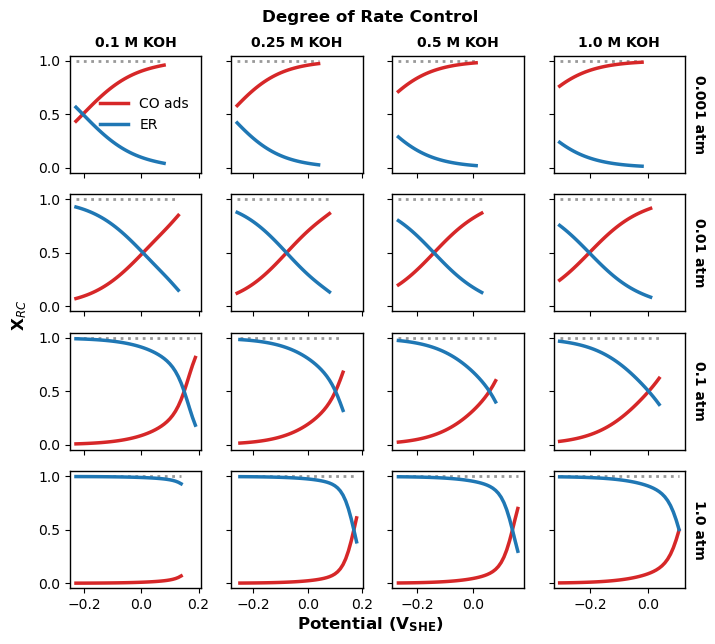

In [5]:
ppc_ER_1_2 = plot_posteriors(trace_ER_1_2, ER_1_2, plot_target)
plot_model_fits(trace_ER_1_2, ppc_ER_1_2, consolidated=True); plot_coverages(trace_ER_1_2)
plot_drc(ER_1_2, trace_ER_1_2, perturb_vars=['delta_BL', 'Gact2_0'], perturb_labels=['CO ads', 'ER'], 
         var_types={'delta_BL': 'resistance', 'Gact2_0': 'Gact'}, target=plot_target)